# 🇻🇳 TFT v3 — No Transfer Learning (VN Only)

**Chiến lược:** Train TFT từ đầu trên dữ liệu Việt Nam (không dùng pretrained weights).

---

### So sánh với Transfer Learning version:

| Phiên bản | Transfer | Biến kinh tế | Ghi chú |
|---|---|---|---|
| **No TL** | ❌ | ✅ | File này — baseline thuần VN |
| TL + No Econ | ✅ | ❌ | Transfer nhưng bỏ kiến tế |
| **TL + Econ** | ✅ | ✅ | transfer_learning_v3.ipynb — full version |

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & PATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, os, json, shutil, copy
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

torch.serialization.add_safe_globals([GroupNormalizer, QuantileLoss])

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}',
      f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')

BASE_DIR       = Path(r'.')
VN_DATA_PATH   = BASE_DIR / 'data' / 'processed' / 'VN_data' / 'vn_tft_ready.csv'
CKPT_DIR       = BASE_DIR / 'checkpoint'
LOG_DIR        = BASE_DIR / 'lightning_logs' / 'tft_vn_v3_no_tl'
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f'VN data : {VN_DATA_PATH}')
print(f'Checkpoint dir: {CKPT_DIR}')

PyTorch : 2.9.1+cu126
Device  : cuda (NVIDIA GeForce RTX 3050 Laptop GPU)
VN data : data\processed\VN_data\vn_tft_ready.csv
Checkpoint dir: checkpoint


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS (Training từ đầu → cần LR cao hơn, epochs nhiều hơn)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    max_encoder_length    = 18,
    max_prediction_length = 6,
    min_series_length     = 24,

    economic_vars = [
        'IPI_Value', 'CPI_Value', 'GDP_trillion', 'Oil_Price',
        'FDI_disbursed', 'gas_price', 'castlecoal_price'
    ],

    val_cutoff_months     = 12,

    hidden_size           = 128,
    attention_head_size   = 4,
    dropout               = 0.2,
    hidden_continuous_size= 32,
    lstm_layers           = 2,
    loss_quantiles        = [0.1, 0.25, 0.5, 0.75, 0.9],

    # ── NO TRANSFER: LR cao hơn, epochs nhiều hơn (training from scratch) ─────
    learning_rate         = 1e-3,  # Higher than TL phase1 (1e-3)
    batch_size            = 32,
    max_epochs            = 100,   # More epochs than TL (was 40+15=55)
    gradient_clip_val     = 0.1,
    patience              = 15,     # More patience
    num_workers           = 0,
    seed                  = 42,
)

pl.seed_everything(CFG['seed'], workers=True)
print('Config VN Training (NO Transfer Learning):')
print(f'  Learning rate: {CFG["learning_rate"]:.0e}')
print(f'  Max epochs: {CFG["max_epochs"]}')
print(f'  Patience: {CFG["patience"]}')

INFO: Seed set to 42


[09:33:07] INFO     Seed set to 42                                   seed.py:57
Config VN Training (NO Transfer Learning):
  Learning rate: 1e-03
  Max epochs: 100
  Patience: 15


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & CHUẨN BỊ DATA (Giống file gốc)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv(VN_DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print(f'Raw VN shape: {df.shape}')

FINE_TUNE_SERIES = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']
df = df[df['series'].isin(FINE_TUNE_SERIES)].copy()
print(f'After filter: {df.shape}')

mu  = df.groupby('entity')['precipitation'].transform('mean')
std = df.groupby('entity')['precipitation'].transform('std').replace(0, 1)
df['prec_zscore'] = (df['precipitation'] - mu) / std

df = df.sort_values(['entity', 'series', 'date'])
df['time_idx'] = df.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df.groupby(['entity', 'series'])[num_cols].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

for var in CFG['economic_vars']:
    df[var] = df.groupby(['entity', 'series'])[var].shift(1)
df[CFG['economic_vars']] = df.groupby(['entity', 'series'])[CFG['economic_vars']].transform(lambda x: x.bfill())

print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')

Raw VN shape: (432, 30)
After filter: (360, 30)
Date range: 2019-01-01 → 2024-12-01


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — FEATURES (Giống file gốc, có biến kinh tế)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STATIC_CATEGORICALS = ['entity']

TIME_VARYING_KNOWN_REALS = [
    'time_idx',
    'month', 'month_sin', 'month_cos', 'quarter', 'year',
    'is_dry_season', 'is_flood_season',
    'quarter_sin', 'quarter_cos',
]

TIME_VARYING_UNKNOWN_REALS = [
    'temperature', 'solar', 'humidity', 'precipitation',
    'log_precipitation', 'prec_zscore', 'temp_anomaly', 'solar_norm',
    'humidity_anomaly', 'prec_lag_1', 'prec_lag_2', 'precip_roll6',
]

if 'precip_roll6' not in df.columns and 'prec_roll_3' in df.columns:
    df['precip_roll6'] = df['prec_roll_3']

TIME_VARYING_UNKNOWN_REALS = list(dict.fromkeys(TIME_VARYING_UNKNOWN_REALS + CFG['economic_vars']))
TIME_VARYING_KNOWN_REALS   = [c for c in TIME_VARYING_KNOWN_REALS   if c in df.columns]
TIME_VARYING_UNKNOWN_REALS = [c for c in TIME_VARYING_UNKNOWN_REALS if c in df.columns]

print(f'Features: {len(TIME_VARYING_UNKNOWN_REALS)} unknown_reals')

training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
print(f'Train/Val split: {(df["time_idx"]<=training_cutoff).sum()} / {(df["time_idx"]>training_cutoff).sum()}')

Features: 13 unknown_reals
Train/Val split: 300 / 60


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — DATALOADERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('\nCreating TimeSeriesDataSet...')
training_vn = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx                         = 'time_idx',
    target                           = 'generation_TWh',
    group_ids                        = ['entity', 'series'],
    min_encoder_length               = CFG['max_encoder_length'] // 2,
    max_encoder_length               = CFG['max_encoder_length'],
    min_prediction_length            = 1,
    max_prediction_length            = CFG['max_prediction_length'],
    static_categoricals              = STATIC_CATEGORICALS,
    static_reals                     = [],
    time_varying_known_categoricals  = ['series'],
    time_varying_known_reals         = TIME_VARYING_KNOWN_REALS,
    time_varying_unknown_categoricals= [],
    time_varying_unknown_reals       = TIME_VARYING_UNKNOWN_REALS,
    target_normalizer                = GroupNormalizer(
        groups         = ['entity', 'series'],
        transformation = 'softplus',
    ),
    add_relative_time_idx  = True,
    add_target_scales      = True,
    add_encoder_length     = True,
    allow_missing_timesteps= True,
)

validation_vn = TimeSeriesDataSet.from_dataset(
    training_vn, df, predict=True, stop_randomization=True
)
print(f'Training samples  : {len(training_vn):,}')
print(f'Validation samples: {len(validation_vn):,}')

train_loader = training_vn.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=CFG['num_workers']
)
val_loader = validation_vn.to_dataloader(
    train=False, batch_size=CFG['batch_size'] * 4, num_workers=CFG['num_workers']
)


Creating TimeSeriesDataSet...


Training samples  : 325
Validation samples: 5


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — BUILD MODEL (NO PRETRAINED WEIGHTS)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = TemporalFusionTransformer.from_dataset(
    training_vn,
    hidden_size            = CFG['hidden_size'],
    attention_head_size    = CFG['attention_head_size'],
    dropout                = CFG['dropout'],
    hidden_continuous_size = CFG['hidden_continuous_size'],
    lstm_layers            = CFG['lstm_layers'],
    loss                   = QuantileLoss(quantiles=CFG['loss_quantiles']),
    learning_rate          = CFG['learning_rate'],
    optimizer              = 'adamw',
    log_interval           = 5,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,} ({n_params/1e6:.2f}M)')
print(f'✅ Training from SCRATCH (no pretrained weights)')

Model parameters: 1,370,772 (1.37M)
✅ Training from SCRATCH (no pretrained weights)


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — TRAINING (Single phase, từ đầu đến cuối)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ckpt = ModelCheckpoint(
    dirpath=str(CKPT_DIR), filename='tft_vn_v3_no_tl_{epoch:02d}_{val_loss:.4f}',
    monitor='val_loss', mode='min', save_top_k=1, save_last=True
)
es = EarlyStopping(
    monitor='val_loss', patience=CFG['patience'], mode='min', verbose=True
)

trainer = pl.Trainer(
    accelerator       = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices           = 1,
    max_epochs        = CFG['max_epochs'],
    gradient_clip_val = CFG['gradient_clip_val'],
    callbacks         = [ckpt, es],
    logger            = TensorBoardLogger(str(BASE_DIR / 'lightning_logs'), name='tft_vn_v3_no_tl'),
    enable_progress_bar = True,
    precision         = '32',
)

print(f'\nTraining: LR={CFG["learning_rate"]:.0e}, max_epochs={CFG["max_epochs"]}, patience={CFG["patience"]}')
print('=' * 60)

model.train()
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

print(f'\nTraining done! Best val_loss = {ckpt.best_model_score:.6f}')

INFO: GPU available: True (cuda), used: True


[09:33:08] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

INFO: Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.698


[09:34:12] INFO     Metric val_loss improved by 0.001 >=  early_stopping.py:305
                    min_delta = 0.0. New best score:                           
                    0.698                                                      


INFO: Monitored metric val_loss did not improve in the last 15 records. Best score: 0.698. Signaling Trainer to stop.


[09:34:49] INFO     Monitored metric val_loss did not     early_stopping.py:305
                    improve in the last 15 records. Best                       
                    score: 0.698. Signaling Trainer to                         
                    stop.                                                      



Training done! Best val_loss = 0.697724


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — SAVE CHECKPOINT & CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL_CKPT = CKPT_DIR / 'tft_vn_v3_no_tl_best.ckpt'

if os.path.exists(ckpt.best_model_path):
    shutil.copy2(ckpt.best_model_path, FINAL_CKPT)
    print(f'Saved: {FINAL_CKPT}')

config = {
    'version'                   : 'tft_vn_v3_no_tl',
    'transfer_learning'         : False,
    'economic_features'         : True,
    'best_ckpt'                 : str(FINAL_CKPT),
    'best_val_loss'             : float(ckpt.best_model_score),
    'max_epochs'                : CFG['max_epochs'],
    'learning_rate'             : CFG['learning_rate'],
    'hidden_size'               : CFG['hidden_size'],
}

cfg_path = CKPT_DIR / 'tft_vn_v3_no_tl_config.json'
with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2)
print(f'Config: {cfg_path}')

Saved: checkpoint\tft_vn_v3_no_tl_best.ckpt
Config: checkpoint\tft_vn_v3_no_tl_config.json


In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — EVALUATION METRICS & FULL TIMELINE PREDICTIONS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
with torch.serialization.safe_globals([GroupNormalizer, QuantileLoss]):
    best_model = TemporalFusionTransformer.load_from_checkpoint(str(FINAL_CKPT))
best_model.eval()

# 1. Tạo loader cho TOÀN BỘ dòng thời gian (Train + Val + Test) để vẽ biểu đồ ở Cell 13
# Chúng ta sử dụng toàn bộ dataframe 'df' và đặt predict=True để lấy dự báo nối tiếp
full_dataset = TimeSeriesDataSet.from_dataset(
    training_vn,
    df,
    predict=True,
    stop_randomization=True
)
full_loader = full_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

# ✅ Lấy raw_preds cho TOÀN BỘ dòng thời gian (dùng cho việc vẽ biểu đồ)
raw_preds = best_model.predict(full_loader, mode='raw', return_x=True, return_index=True)

# 2. Tính Metrics trên tập Validation (Giữ nguyên val_loader để kết quả đánh giá khách quan)
point_preds = best_model.predict(val_loader, mode='prediction', return_x=True)
pred_vals = point_preds.output

# Đảm bảo pred_vals nằm trên cùng device với actuals để tính toán
actuals = torch.cat([y[0] for _, y in val_loader]).to(pred_vals.device)

# Tính toán các chỉ số
mae   = (actuals - pred_vals).abs().mean().item()
rmse  = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape = (2*(actuals - pred_vals).abs() / (actuals.abs() + pred_vals.abs() + 1e-8)).mean().item() * 100
wape  = ((actuals - pred_vals).abs().sum() / (actuals.abs().sum() + 1e-8)).item() * 100
r2    = (1 - ((actuals - pred_vals) ** 2).sum() / ((actuals - actuals.mean()) ** 2).sum()).item()

print(f'\n📊 Validation Metrics (NO Transfer Learning):')  
print(f'   MAE   : {mae:.4f} TWh')
print(f'   RMSE  : {rmse:.4f} TWh')
print(f'   R2    : {r2:.4f}')
print(f'   SMAPE : {smape:.2f}%')
print(f'   WAPE  : {wape:.2f}%')

INFO: GPU available: True (cuda), used: True


[09:36:50] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[09:36:51] INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61

📊 Validation Metrics (NO Transfer Learning):
   MAE   : 1.1209 TWh
   RMSE  : 1.5444 TWh
   R2    : 0.8883
   SMAPE : 31.57%
   WAPE  : 21.00%


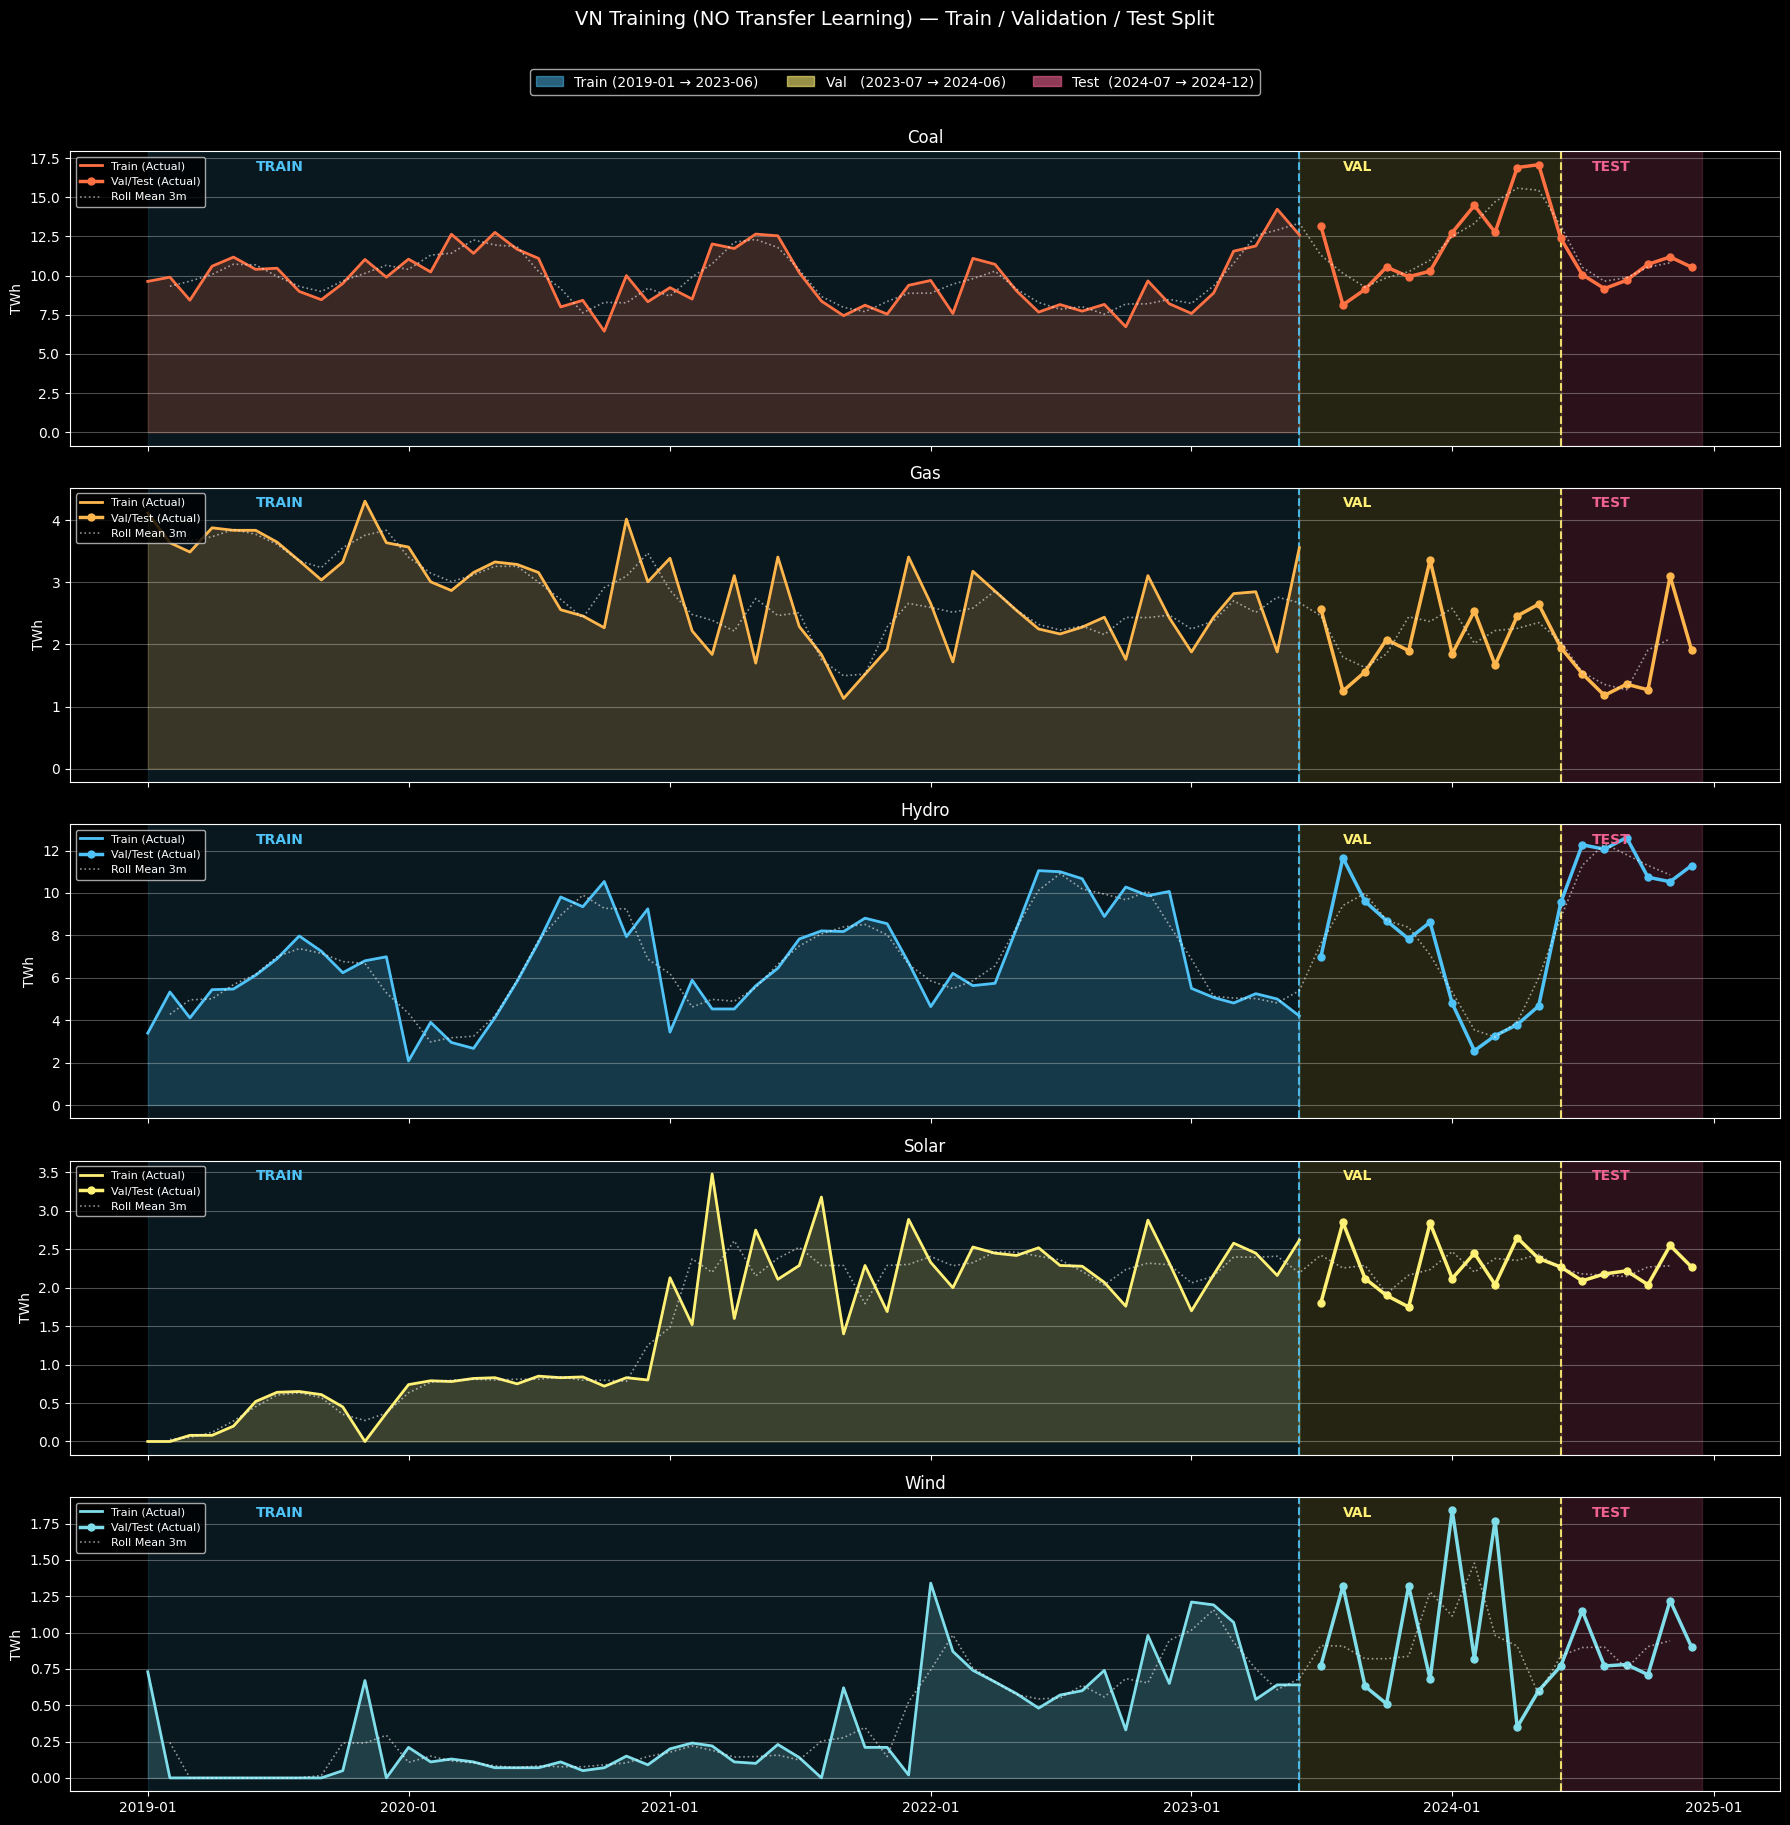

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — VISUALIZATION: TRAIN/VAL/TEST SPLIT (Giống file gốc)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.patches as mpatches

SERIES_COLORS = {
    'Coal': '#ff7043', 'Gas': '#ffb74d',
    'Hydro': '#4fc3f7', 'Solar': '#fff176', 'Wind': '#80deea',
}

TRAIN_END = pd.Timestamp('2023-06-01')
VAL_END   = pd.Timestamp('2024-06-01')
TEST_END  = df['date'].max()

fig, axes = plt.subplots(len(FINE_TUNE_SERIES), 1,
                         figsize=(18, 3.5 * len(FINE_TUNE_SERIES)),
                         sharex=True)

for ax, ser in zip(axes, FINE_TUNE_SERIES):
    sub   = df[df['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#aaa')

    ax.axvspan(sub['date'].min(), TRAIN_END, alpha=0.12, color='#4fc3f7')
    ax.axvspan(TRAIN_END, VAL_END, alpha=0.15, color='#fff176')
    ax.axvspan(VAL_END, TEST_END + pd.DateOffset(days=15), alpha=0.18, color='#f06292')

    ax.axvline(TRAIN_END, color='#4fc3f7', linewidth=1.5, linestyle='--', alpha=0.9)
    ax.axvline(VAL_END, color='#fff176', linewidth=1.5, linestyle='--', alpha=0.9)

    train_sub = sub[sub['date'] <= TRAIN_END]
    ax.plot(train_sub['date'], train_sub['generation_TWh'],
            color=color, linewidth=2.0, label='Train (Actual)')
    ax.fill_between(train_sub['date'], train_sub['generation_TWh'], alpha=0.2, color=color)

    val_test_sub = sub[sub['date'] > TRAIN_END]
    ax.plot(val_test_sub['date'], val_test_sub['generation_TWh'],
            color=color, linewidth=2.5, marker='o', markersize=5, label='Val/Test (Actual)')

    roll = sub.set_index('date')['generation_TWh'].rolling(3, center=True).mean()
    ax.plot(roll.index, roll.values, color='white', linewidth=1.2, alpha=0.55, linestyle=':', label='Roll Mean 3m')

    y_top = sub['generation_TWh'].max() * 1.05
    ax.text(pd.Timestamp('2019-06-01'), y_top * 0.93, 'TRAIN', color='#4fc3f7', fontsize=10, fontweight='bold')
    ax.text(pd.Timestamp('2023-08-01'), y_top * 0.93, 'VAL', color='#fff176', fontsize=10, fontweight='bold')
    ax.text(pd.Timestamp('2024-07-15'), y_top * 0.93, 'TEST', color='#f06292', fontsize=10, fontweight='bold')

    ax.set_ylabel('TWh', fontsize=10)
    ax.set_title(f'{ser}', fontsize=12, pad=6)
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.legend(loc='upper left', fontsize=8)

legend_patches = [
    mpatches.Patch(color='#4fc3f7', alpha=0.5, label='Train (2019-01 → 2023-06)'),
    mpatches.Patch(color='#fff176', alpha=0.6, label='Val   (2023-07 → 2024-06)'),
    mpatches.Patch(color='#f06292', alpha=0.6, label='Test  (2024-07 → 2024-12)'),
]
fig.legend(handles=legend_patches, loc='upper center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, 1.01))
fig.suptitle('VN Training (NO Transfer Learning) — Train / Validation / Test Split', fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

📊 FEATURE IMPORTANCE — No Transfer Learning (With Economic Features)

  Aligned importance from 18 to 17 features
Top 15 Most Important Encoder Variables:
────────────────────────────────────────────────────────────
 1. FDI_disbursed                  ███████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 22.56%
 2. time_idx                       █████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 19.98%
 3. gas_price                      █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 11.15%
 4. Oil_Price                      ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  8.31%
 5. temperature                    ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  7.10%
 6. series                         ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  5.24%
 7. castlecoal_price               █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  3.48%
 8. GDP_trillion                   █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  3.03%
 9. humidity                       █░░░░

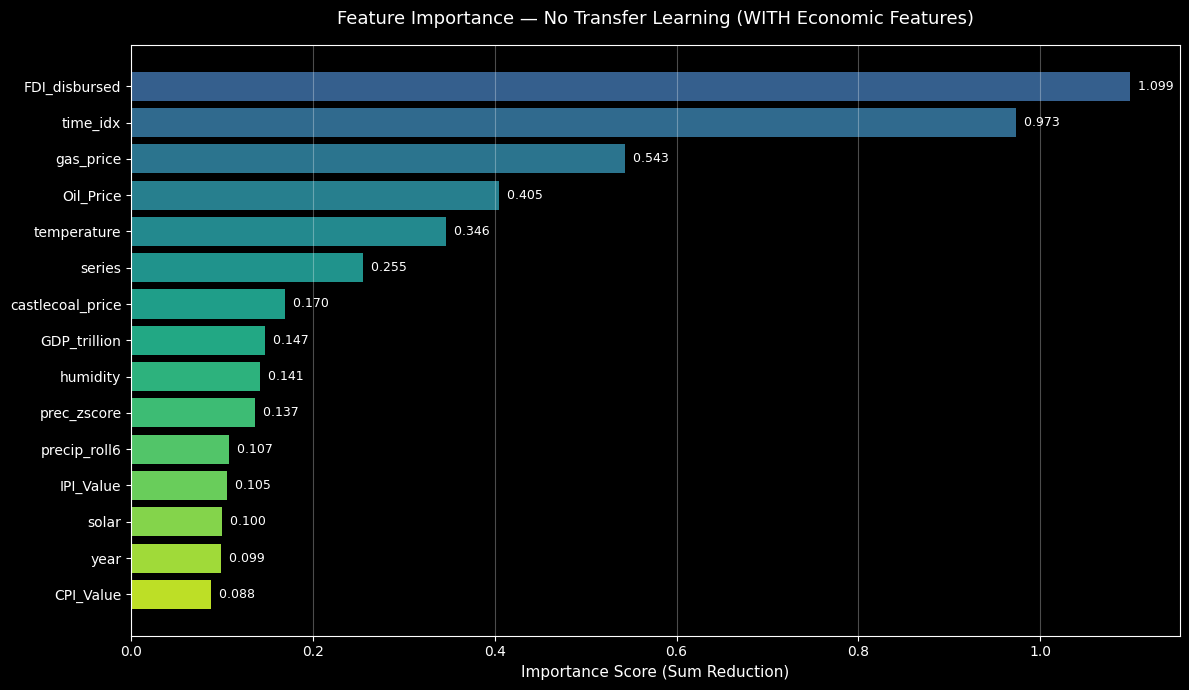


✓ Feature importance extracted and visualized successfully



In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — FEATURE IMPORTANCE ANALYSIS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('📊 FEATURE IMPORTANCE — No Transfer Learning (With Economic Features)\n')

# Interpret model predictions
interpretation = best_model.interpret_output(raw_preds.output, reduction='sum')

# Extract encoder variable importance
enc_importance = interpretation.get('encoder_variables')
if enc_importance is not None:
    # Convert tensor to numpy
    if hasattr(enc_importance, 'detach'):
        enc_vals = enc_importance.detach().cpu().numpy()
    else:
        enc_vals = np.asarray(enc_importance)
    
    # Handle multi-dimensional case by reshaping
    if enc_vals.ndim > 1:
        enc_vals = np.abs(enc_vals).reshape(-1, enc_vals.shape[-1]).mean(axis=0)
    else:
        enc_vals = np.abs(enc_vals)
    
    # Get all feature names in order
    known_reals = list(training_vn.time_varying_known_reals)
    unknown_reals = list(training_vn.time_varying_unknown_reals)
    known_cats = list(training_vn.time_varying_known_categoricals)
    
    all_features = known_reals + unknown_reals + known_cats
    
    # Handle mismatch: if importance has fewer or more values, pad or truncate
    if len(enc_vals) != len(all_features):
        # Take only as many importance scores as we have features
        enc_vals_aligned = enc_vals[:len(all_features)] if len(enc_vals) > len(all_features) else np.pad(enc_vals, (0, len(all_features) - len(enc_vals)), mode='constant')
        print(f'  Aligned importance from {len(enc_vals)} to {len(all_features)} features')
    else:
        enc_vals_aligned = enc_vals
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': enc_vals_aligned
    }).sort_values('Importance', ascending=False)
    
    print('Top 15 Most Important Encoder Variables:')
    print('─' * 60)
    for idx, (feat, imp) in enumerate(importance_df.head(15).values, 1):
        pct = (imp / importance_df['Importance'].sum() * 100) if importance_df['Importance'].sum() > 0 else 0
        bar = '█' * int(pct / 2) + '░' * (50 - int(pct / 2))
        print(f'{idx:2d}. {feat:<30} {bar} {pct:>5.2f}%')
    
    # Visualize top 15
    fig, ax = plt.subplots(figsize=(12, 7))
    top_15 = importance_df.head(15)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_15)))
    
    bars = ax.barh(range(len(top_15)), top_15['Importance'].values, color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'].values, fontsize=10)
    ax.set_xlabel('Importance Score (Sum Reduction)', fontsize=11)
    ax.set_title('Feature Importance — No Transfer Learning (WITH Economic Features)', fontsize=13, pad=15)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (feat, val) in enumerate(zip(top_15['Feature'].values, top_15['Importance'].values)):
        ax.text(val, i, f'  {val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print('\n✓ Feature importance extracted and visualized successfully')
else:
    print('⚠ Encoder variable importance not found in interpretation')

print()


INFO: GPU available: True (cuda), used: True


[09:40:18] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[09:40:19] INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61


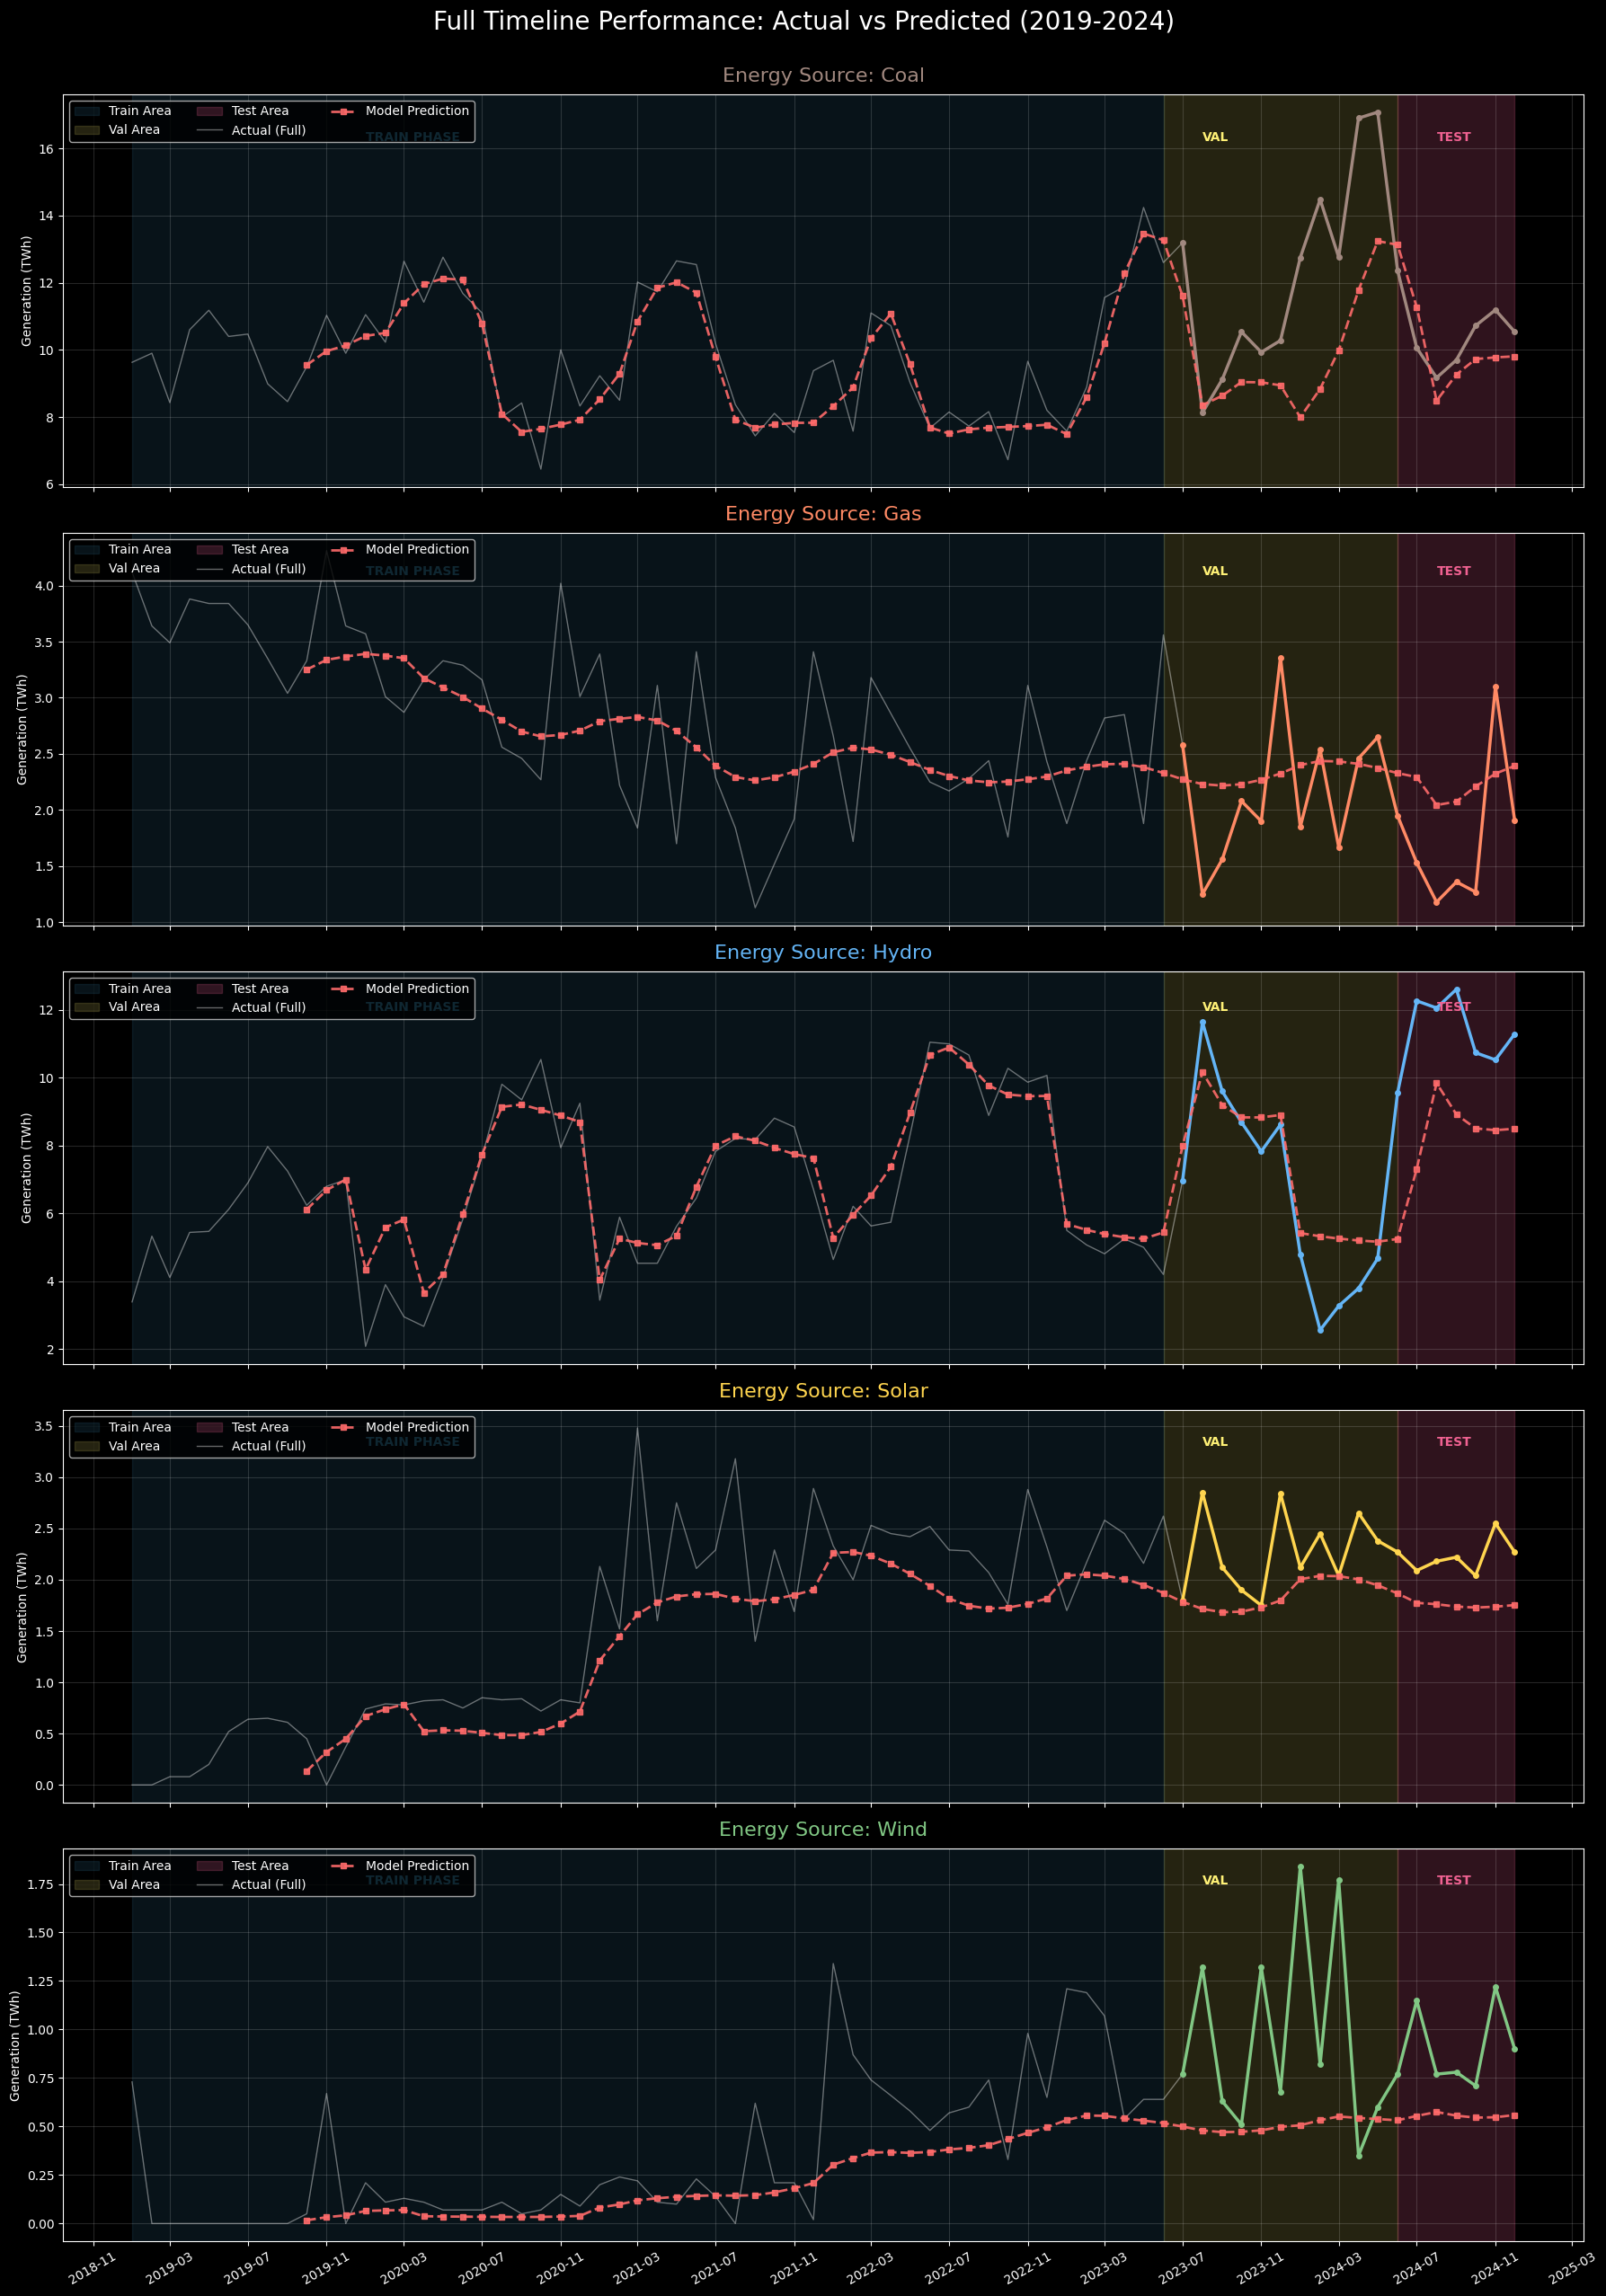

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 13 — FULL TIMELINE VISUALIZATION (TRAIN - VAL - TEST)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Định nghĩa bảng màu cho từng loại năng lượng
SERIES_COLORS = {
    "Nuclear": "#4db6ac",    # Màu xanh ngọc
    "Hydro": "#64b5f6",      # Màu xanh dương
    "Wind": "#81c784",       # Màu xanh lá
    "Solar": "#ffd54f",      # Màu vàng
    "Coal": "#a1887f",       # Màu nâu/xám
    "Gas": "#ff8a65",        # Màu cam
    "Biomass": "#ce93d8"     # Màu tím
}

# Lưu ý: Các tên "Nuclear", "Hydro"... phải khớp chính xác với tên trong cột 'series' của bạn

plt.style.use('dark_background')

# Mốc thời gian cho biểu đồ này. Định nghĩa tại đây để cell có thể chạy độc lập.
TRAIN_END = pd.Timestamp('2023-06-01')
VAL_END = pd.Timestamp('2024-06-01')
TEST_END = df['date'].max()

# 1. Hàm chuyển đổi an toàn
def to_np(obj):
    if hasattr(obj, 'prediction'): obj = obj.prediction
    if torch.is_tensor(obj): return obj.detach().cpu().numpy()
    if isinstance(obj, dict): return {k: to_np(v) for k, v in obj.items()}
    return obj

# 2. Tạo dataset trượt trên TOÀN BỘ chuỗi để lấy dự báo cho cả train/val/test.
# Không dùng predict=True vì chế độ đó chỉ lấy cửa sổ cuối cùng của mỗi series.
full_dataset = TimeSeriesDataSet.from_dataset(
    training_vn,
    df,
    stop_randomization=True
)
full_loader = full_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

# 3. Xử lý dữ liệu dự báo
raw_preds = best_model.predict(full_loader, mode='raw', return_x=True, return_index=True)
preds_all = to_np(raw_preds.output)
x_data = to_np(raw_preds.x)
if preds_all.ndim == 3:
    pred_values = preds_all[:, :, preds_all.shape[2] // 2]
else:
    pred_values = preds_all

# 4. Tạo DataFrame dự báo tổng hợp
if raw_preds.index is None:
    print("❌ LỖI: Bạn phải thêm return_index=True vào lệnh predict()")
else:
    idx_df = raw_preds.index.copy()
    for col in idx_df.columns:
        idx_df[col] = idx_df[col].apply(lambda x: x.item() if torch.is_tensor(x) else x)

    all_preds_list = []
    for i in range(len(idx_df)):
        all_preds_list.append(pd.DataFrame({
            'series': idx_df.iloc[i]['series'],
            'time_idx': x_data['decoder_time_idx'][i].astype(int),
            'pred': pred_values[i]
        }))
    
    # Gộp tất cả các window dự báo, lấy trung bình nếu bị chồng lấn
    pred_df_final = pd.concat(all_preds_list).groupby(['series', 'time_idx']).mean().reset_index()
    time_map = df[['series', 'time_idx', 'date']].drop_duplicates(['series', 'time_idx'])
    pred_df_final = pred_df_final.merge(time_map, on=['series', 'time_idx'], how='left')

    # 5. Vẽ biểu đồ
    fig, axes = plt.subplots(len(FINE_TUNE_SERIES), 1, 
                             figsize=(18, 5 * len(FINE_TUNE_SERIES)), sharex=True)
    if len(FINE_TUNE_SERIES) == 1: axes = [axes]

    for ax, ser in zip(axes, FINE_TUNE_SERIES):
        sub = df[df['series'] == ser].sort_values('date')
        color = SERIES_COLORS.get(ser, '#aaa')

        # Vùng màu nền
        ax.axvspan(sub['date'].min(), TRAIN_END, alpha=0.1, color='#4fc3f7', label='Train Area')
        ax.axvspan(TRAIN_END, VAL_END, alpha=0.15, color='#fff176', label='Val Area')
        ax.axvspan(VAL_END, sub['date'].max(), alpha=0.2, color='#f06292', label='Test Area')

        # --- ĐƯỜNG THỰC TẾ (FULL) ---
        # Vẽ đường mảnh màu trắng làm nền cho toàn bộ lịch sử
        ax.plot(sub['date'], sub['generation_TWh'], color='white', lw=1, alpha=0.4, label='Actual (Full)')
        
        # Vẽ đậm đoạn thực tế sau Train (Val + Test)
        vt_actual = sub[sub['date'] > TRAIN_END]
        ax.plot(vt_actual['date'], vt_actual['generation_TWh'], color=color, lw=2.5, marker='o', ms=4)

        # --- ĐƯỜNG DỰ BÁO (FULL) ---
        psub = pred_df_final[pred_df_final['series'] == ser].sort_values('date')
        if not psub.empty:
            # Đường dự báo màu đỏ neon để nổi bật trên nền tối
            ax.plot(psub['date'], psub['pred'], color='#ff6b6b', ls='--', lw=2, 
                    marker='s', ms=4, alpha=0.9, label='Model Prediction')

        # Định dạng trục
        ax.set_title(f"Energy Source: {ser}", fontsize=16, color=color, pad=10)
        ax.set_ylabel("Generation (TWh)")
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
        ax.grid(True, alpha=0.15)
        ax.legend(loc='upper left', ncol=3)

        # Chú thích Text
        y_loc = sub['generation_TWh'].max() * 0.95
        ax.text(pd.Timestamp('2020-01-01'), y_loc, 'TRAIN PHASE', color='#4fc3f7', fontweight='bold')
        ax.text(TRAIN_END + pd.DateOffset(months=2), y_loc, 'VAL', color='#fff176', fontweight='bold')
        ax.text(VAL_END + pd.DateOffset(months=2), y_loc, 'TEST', color='#f06292', fontweight='bold')

    plt.xticks(rotation=30)
    plt.tight_layout()
    fig.suptitle('Full Timeline Performance: Actual vs Predicted (2019-2024)', fontsize=20, y=1.02)
    plt.show()